**Лачина Екатерина Андреевна, ИУ5-63Б**

**Рубежный контроль 1. Вариант 10. Задача 2. Датасет 2 (wine)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

In [ ]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [ ]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Датасет содержит только числовые признаки. Создадим категориальный признак `alcohol_level` на основе содержания алкоголя, разбив значения на три категории по квантилям.

In [ ]:
q1, q2 = df['alcohol'].quantile([1/3, 2/3])

def categorize_alcohol(val):
    if val < q1:
        return 'low'
    elif val < q2:
        return 'medium'
    else:
        return 'high'

df['alcohol_level'] = df['alcohol'].apply(categorize_alcohol)
df['alcohol_level'].value_counts()

alcohol_level
high      61
low       59
medium    58
Name: count, dtype: int64

Искусственно вводим пропуски в количественный признак `magnesium` (20% значений) и в категориальный `alcohol_level` (15% значений).

In [ ]:
np.random.seed(42)

n = len(df)
idx_num = np.random.choice(n, size=int(0.2 * n), replace=False)
idx_cat = np.random.choice(n, size=int(0.15 * n), replace=False)

df.loc[idx_num, 'magnesium'] = np.nan
df.loc[idx_cat, 'alcohol_level'] = np.nan

print("Пропуски после введения:")
print(df[['magnesium', 'alcohol_level']].isnull().sum())

Пропуски после введения:
magnesium        35
alcohol_level    26
dtype: int64


### Обработка пропусков

**Количественный признак `magnesium`** — заполняем медианой. Медиана предпочтительнее среднего, так как устойчива к выбросам. Содержание магния в вине может иметь выбросы (отдельные сорта резко отличаются от остальных), поэтому медиана даёт более робастную оценку центра распределения.

**Категориальный признак `alcohol_level`** — заполняем модой, то есть наиболее часто встречающейся категорией. Это стандартный подход для категориальных данных.

In [ ]:
median_magnesium = df['magnesium'].median()
mode_alcohol_level = df['alcohol_level'].mode()[0]

df['magnesium'] = df['magnesium'].fillna(median_magnesium)
df['alcohol_level'] = df['alcohol_level'].fillna(mode_alcohol_level)

print(f"Медиана magnesium: {median_magnesium}")
print(f"Мода alcohol_level: {mode_alcohol_level}")
print("\nПропуски после обработки:")
print(df[['magnesium', 'alcohol_level']].isnull().sum())

Медиана magnesium: 98.0
Мода alcohol_level: high

Пропуски после обработки:
magnesium        0
alcohol_level    0
dtype: int64


### Boxplot для признака `flavanoids`

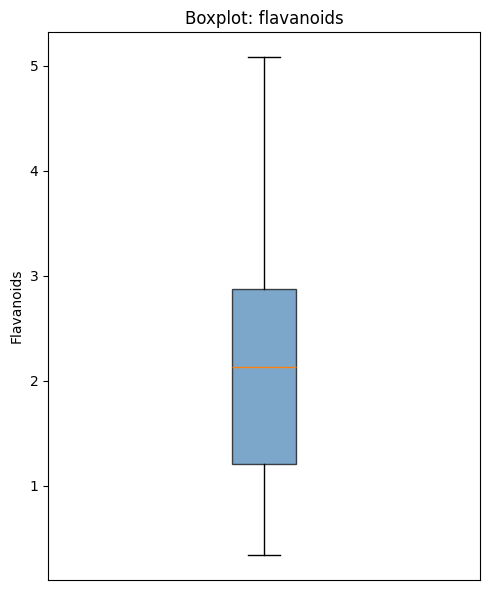

In [ ]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.boxplot(df['flavanoids'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_title('Boxplot: flavanoids')
ax.set_ylabel('Flavanoids')
ax.set_xticks([])
plt.tight_layout()
plt.show()

### Выбор признаков для построения моделей

Целевая переменная — `target` (класс вина, 3 класса). Для построения модели классификации используем числовые признаки из исходного датасета. 

Исключаем из рассмотрения созданный категориальный признак `alcohol_level`, поскольку он полностью производен от `alcohol` — использование обоих вместе привело бы к дублированию информации. Признак `alcohol` при этом сохраняем.

Исходные 13 числовых признаков (`alcohol`, `malic_acid`, `ash`, `alcalinity_of_ash`, `magnesium`, `total_phenols`, `flavanoids`, `nonflavanoid_phenols`, `proanthocyanins`, `color_intensity`, `hue`, `od280/od315_of_diluted_wines`, `proline`) используются все, так как они характеризуют химический состав и физические свойства вина — информативны для разделения сортов. Датасет небольшой (178 строк, 13 признаков), мультиколлинеарность можно будет при необходимости устранить на этапе отбора признаков.

In [ ]:
feature_cols = wine.feature_names
X = df[feature_cols]
y = df['target']

print("Признаки для модели:", feature_cols)
print("Размерность X:", X.shape)
print("Распределение классов:")
print(y.value_counts().sort_index())

Признаки для модели: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Размерность X: (178, 13)
Распределение классов:
target
0    59
1    71
2    48
Name: count, dtype: int64
